# India Air Quality & Crop Yield — EDA Lab

**Student ID:** 2547116

**Aim:** Check whether states with worse air quality also produce less crop, using two real, messy datasets.

**Files:**
- `city_day.csv` — city-day air quality (PM2.5, PM10, NO2, CO, AQI), 2015-2020.
- `crop_production.csv` — district-crop-year production records, 1997-2015.

Both are raw Kaggle data, not cleaned up for this lab. Covers Lab 1 (Tasks 1-5) and Lab 2 (Tasks 6-9 + optional) in one notebook.

## 0. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Libraries loaded.")

Libraries loaded.


Just the usual EDA stack, nothing fancy needed.

## 0.1 Load the Datasets

In [2]:
air_raw = pd.read_csv("city_day.csv/city_day.csv")
crop_raw = pd.read_csv("crop_production.csv/crop_production.csv")

print("Air quality data:", air_raw.shape)
display(air_raw.head())

print("Crop production data:", crop_raw.shape)
display(crop_raw.head())

Air quality data: (29531, 16)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


Crop production data: (246091, 7)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0


Air data is one row per city per day, crop data is one row per district per crop per year. Different shapes already — merging these later won't be simple.

# Lab 1 — Data Preprocessing & Visualisation

## Task 1: First-Impression Data Profile

Before trusting this data: how big is it, how much is missing, and what looks broken?

In [3]:
print("AIR QUALITY DATA")
print("Shape:", air_raw.shape)
air_raw.info()

AIR QUALITY DATA
Shape: (29531, 16)
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  str    
 1   Date        29531 non-null  str    
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  str    
dtypes: float64(13), str(3)
memory usage: 3.6 MB


In [4]:
print("CROP PRODUCTION DATA")
print("Shape:", crop_raw.shape)
crop_raw.info()

CROP PRODUCTION DATA
Shape: (246091, 7)
<class 'pandas.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  str    
 1   District_Name  246091 non-null  str    
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  str    
 4   Crop           246091 non-null  str    
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 13.1 MB


In [5]:
air_missing = air_raw.isna().mean().mul(100).round(1).sort_values(ascending=False)
crop_missing = crop_raw.isna().mean().mul(100).round(1).sort_values(ascending=False)

print("Missing % - air data:")
print(air_missing)
print()
print("Missing % - crop data:")
print(crop_missing)

Missing % - air data:
Xylene        61.3
PM10          37.7
NH3           35.0
Toluene       27.2
Benzene       19.0
AQI           15.9
AQI_Bucket    15.9
PM2.5         15.6
NOx           14.2
O3            13.6
SO2           13.1
NO2           12.1
NO            12.1
CO             7.0
Date           0.0
City           0.0
dtype: float64

Missing % - crop data:
Production       1.5
District_Name    0.0
State_Name       0.0
Crop_Year        0.0
Season           0.0
Crop             0.0
Area             0.0
dtype: float64


In [6]:
print("Exact duplicate rows - air:", air_raw.duplicated().sum())
print("Exact duplicate rows - crop:", crop_raw.duplicated().sum())

print()
print("Cities in air data:", air_raw["City"].nunique())
print("States in crop data:", crop_raw["State_Name"].nunique())
print()
print("Air date range:", air_raw["Date"].min(), "to", air_raw["Date"].max())
print("Crop year range:", crop_raw["Crop_Year"].min(), "to", crop_raw["Crop_Year"].max())
print()
print("AQI summary:")
print(air_raw["AQI"].describe())

Exact duplicate rows - air: 0


Exact duplicate rows - crop:

 0

Cities in air data: 26
States in crop data: 33

Air date range: 2015-01-01 to 2020-07-01
Crop year range: 1997 to 2015

AQI summary:
count    24850.000000
mean       166.463581
std        140.696585
min         13.000000
25%         81.000000
50%        118.000000
75%        208.000000
max       2049.000000
Name: AQI, dtype: float64


**city_day.csv**

| Aspect | Detail |
|---|---|
| Size | 29,531 rows x 16 cols, one row per city per day |
| Coverage | 26 cities, Jan 2015 - Jul 2020 |
| Missing data | very uneven — some cols ~7-12%, Xylene **61%** |
| Duplicates | none |
| Odd values | AQI hits **2049** somewhere (real scale tops out ~500) |
| Other | no `State` column, only `City` |

**crop_production.csv**

| Aspect | Detail |
|---|---|
| Size | 246,091 rows x 7 cols, one row per district-crop-year |
| Coverage | 33 states/UTs, 1997-2015 |
| Missing data | only `Production`, and just 1.5% |
| Duplicates | none |
| Odd values | state names and every `Season` value have trailing spaces |

**Biggest concern:** the two files barely share a time window — air data starts right when crop data ends, so matching by year won't work well. A couple of pollutant columns are too empty to trust, that AQI of 2049 is clearly bad data, and I'll need to strip whitespace before grouping states or the same state will get split into two groups.

## Task 2: Missing Value Treatment

Not treating every column the same way here — dropping everything or filling everything with the mean would be lazy.

**Air data:**
- `Xylene`, `NH3`, `Toluene`, `AQI_Bucket` → **drop the columns**. Not needed for this analysis, and mostly empty anyway.
- `PM2.5`, `PM10`, `NO2`, `CO` → **fill with each city's median**. Pollution varies a lot city to city, so one global number would be misleading. Median over mean because these values are skewed.
- `AQI` (16% missing) → **drop the rows**. It's the main variable everything else depends on — didn't want to guess it.

**Crop data:**
- `Production` (1.5% missing) → **drop the rows**. Barely any loss, not worth imputing.

In [7]:
air = air_raw.copy()
crop = crop_raw.copy()

print("Missing values BEFORE treatment (air):")
print(air.isna().sum())
print()
print("Missing values BEFORE treatment (crop):")
print(crop["Production"].isna().sum())

Missing values BEFORE treatment (air):
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Missing values BEFORE treatment (crop):
3730


In [8]:
# Drop pollutant columns that are barely usable or not needed for this lab
air = air.drop(columns=["NH3", "NOx", "NO", "O3", "SO2", "Benzene", "Toluene", "Xylene", "AQI_Bucket"])

# AQI is the key variable - drop rows where it's missing rather than guess it
air = air.dropna(subset=["AQI"])

# Remaining pollutants: fill gaps with each city's own median.
# A couple of cities have NO PM10 readings at all, so their "city median" is
# also NaN - catch those leftovers with the overall column median.
for col in ["PM2.5", "PM10", "NO2", "CO"]:
    air[col] = air.groupby("City")[col].transform(lambda s: s.fillna(s.median()))
    air[col] = air[col].fillna(air[col].median())

# Crop: drop the small number of rows missing Production
crop = crop.dropna(subset=["Production"])

print("Missing values AFTER treatment (air):")
print(air.isna().sum())
print()
print("Missing values AFTER treatment (crop):", crop["Production"].isna().sum())
print()
print("Air rows remaining:", len(air))
print("Crop rows remaining:", len(crop))

Missing values AFTER treatment (air):
City     0
Date     0
PM2.5    0
PM10     0
NO2      0
CO       0
AQI      0
dtype: int64

Missing values AFTER treatment (crop): 0

Air rows remaining: 24850
Crop rows remaining: 242361


Zero nulls left in both files. Air data lost about 16% of its rows — all the ones with no AQI — which is a fair trade for not faking the most important column.

## Task 3: State Names & Duplicate Records

Air data only has `City`, so I need a state for each one before it can ever join to the crop file. Crop's state names also have stray whitespace that would quietly create fake duplicate states.

In [9]:
city_to_state = {
    "Ahmedabad": "Gujarat", "Aizawl": "Mizoram", "Amaravati": "Andhra Pradesh",
    "Amritsar": "Punjab", "Bengaluru": "Karnataka", "Bhopal": "Madhya Pradesh",
    "Brajrajnagar": "Odisha", "Chandigarh": "Chandigarh", "Chennai": "Tamil Nadu",
    "Coimbatore": "Tamil Nadu", "Delhi": "Delhi", "Ernakulam": "Kerala",
    "Gurugram": "Haryana", "Guwahati": "Assam", "Hyderabad": "Telangana",
    "Jaipur": "Rajasthan", "Jorapokhar": "Jharkhand", "Kochi": "Kerala",
    "Kolkata": "West Bengal", "Lucknow": "Uttar Pradesh", "Mumbai": "Maharashtra",
    "Patna": "Bihar", "Shillong": "Meghalaya", "Talcher": "Odisha",
    "Thiruvananthapuram": "Kerala", "Visakhapatnam": "Andhra Pradesh",
}

air["State"] = air["City"].map(city_to_state)
print("Cities with no state match:", air.loc[air["State"].isna(), "City"].unique())

Cities with no state match: <StringArray>
[]
Length: 0, dtype: str


In [10]:
print("Crop state names with extra whitespace, before cleaning:")
print([s for s in crop["State_Name"].unique() if s != s.strip()])
print("Crop season values before cleaning:")
print(crop["Season"].unique())

crop["State_Name"] = crop["State_Name"].str.strip()
crop["Season"] = crop["Season"].str.strip()
crop["Crop"] = crop["Crop"].str.strip()

print()
print("Crop season values after cleaning:")
print(crop["Season"].unique())

Crop state names with extra whitespace, before cleaning:
['Jammu and Kashmir ', 'Telangana ']
Crop season values before cleaning:
<StringArray>
['Kharif     ', 'Whole Year ', 'Autumn     ', 'Rabi       ', 'Summer     ',
 'Winter     ']
Length: 6, dtype: str



Crop season values after cleaning:
<StringArray>
['Kharif', 'Whole Year', 'Autumn', 'Rabi', 'Summer', 'Winter']
Length: 6, dtype: str


In [11]:
air_before, crop_before = len(air), len(crop)

air = air.drop_duplicates()
crop = crop.drop_duplicates(subset=["State_Name", "District_Name", "Crop_Year", "Season", "Crop"])

pd.DataFrame({
    "Dataset": ["air", "crop"],
    "Rows before": [air_before, crop_before],
    "Rows after": [len(air), len(crop)],
    "Duplicates removed": [air_before - len(air), crop_before - len(crop)],
})

,Dataset,Rows before,Rows after,Duplicates removed
0,air,24850,24850,0
1,crop,242361,242361,0


**Found and fixed:**
- No `State` column in air data — added one with a city-to-state lookup. Every city matched.
- Some crop state names, and *every* `Season` value, had trailing spaces — `.str.strip()` sorted both.
- Checked for exact duplicate rows and repeated state-district-crop-year-season combos in both files. Genuinely none — good, but worth checking rather than assuming.

Skipping the whitespace fix would've quietly split `"Telangana"` and `"Telangana "` into two different states later.

## Task 4: Where Do Cities Sit on the AQI Scale?

Two questions: where do most values cluster (histogram), and is the mean skewed by a few extreme readings (boxplot). Using both, side by side.

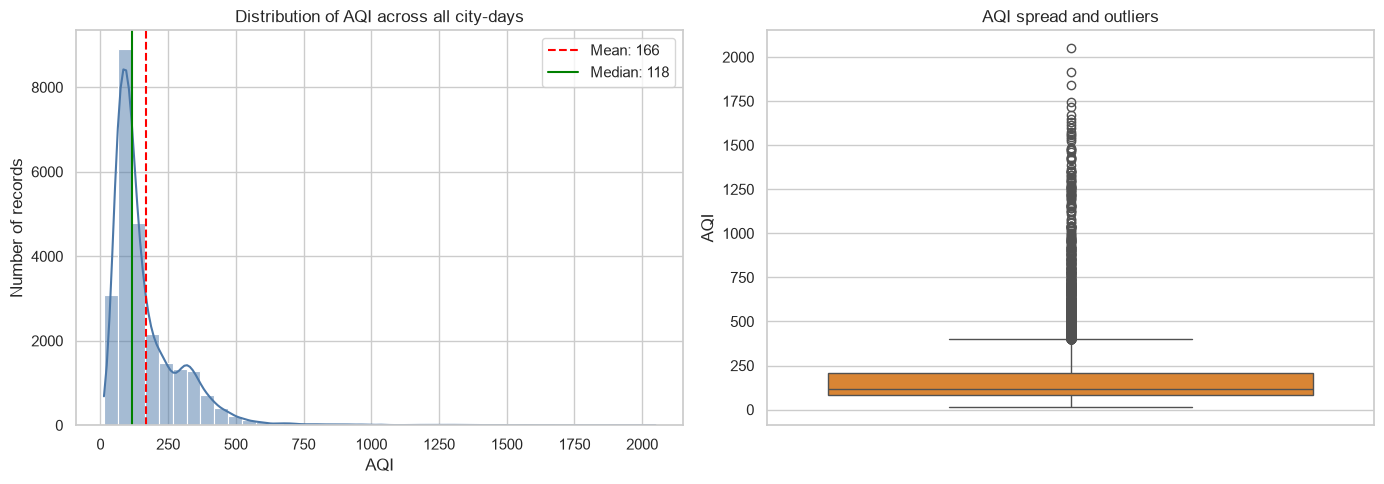

Mean AQI: 166.5, Median AQI: 118.0


In [12]:
mean_aqi = air["AQI"].mean()
median_aqi = air["AQI"].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(air["AQI"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].axvline(mean_aqi, color="red", linestyle="--", label=f"Mean: {mean_aqi:.0f}")
axes[0].axvline(median_aqi, color="green", linestyle="-", label=f"Median: {median_aqi:.0f}")
axes[0].set_title("Distribution of AQI across all city-days")
axes[0].set_xlabel("AQI")
axes[0].set_ylabel("Number of records")
axes[0].legend()

sns.boxplot(y=air["AQI"], ax=axes[1], color="#F58518")
axes[1].set_title("AQI spread and outliers")
axes[1].set_ylabel("AQI")

plt.tight_layout()
plt.show()

print(f"Mean AQI: {mean_aqi:.1f}, Median AQI: {median_aqi:.1f}")

Most city-days sit in the moderate-to-poor range (roughly 80-200) — pollution's a widespread problem, not just a few bad cities. Mean is well above median, and the boxplot shows a long tail past 500, so a handful of very bad days are dragging the average up. Median's the fairer number to report publicly.

## Task 5: Handling Extreme AQI Values

The real AQI scale tops out around 400-500 ("Severe"). Anything way past that is a sensor glitch, not a real reading. Using the IQR rule to catch these automatically, then capping (not deleting) so I keep the row.

In [13]:
q1 = air["AQI"].quantile(0.25)
q3 = air["AQI"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

extreme_count = (air["AQI"] > upper_bound).sum()
print(f"Upper bound from IQR rule: {upper_bound:.1f}")
print(f"Values above this bound: {extreme_count} out of {len(air)} rows ({extreme_count/len(air)*100:.1f}%)")

air_before_capping = air["AQI"].copy()
air["AQI"] = air["AQI"].clip(upper=upper_bound)

Upper bound from IQR rule: 398.5
Values above this bound: 1358 out of 24850 rows (5.5%)


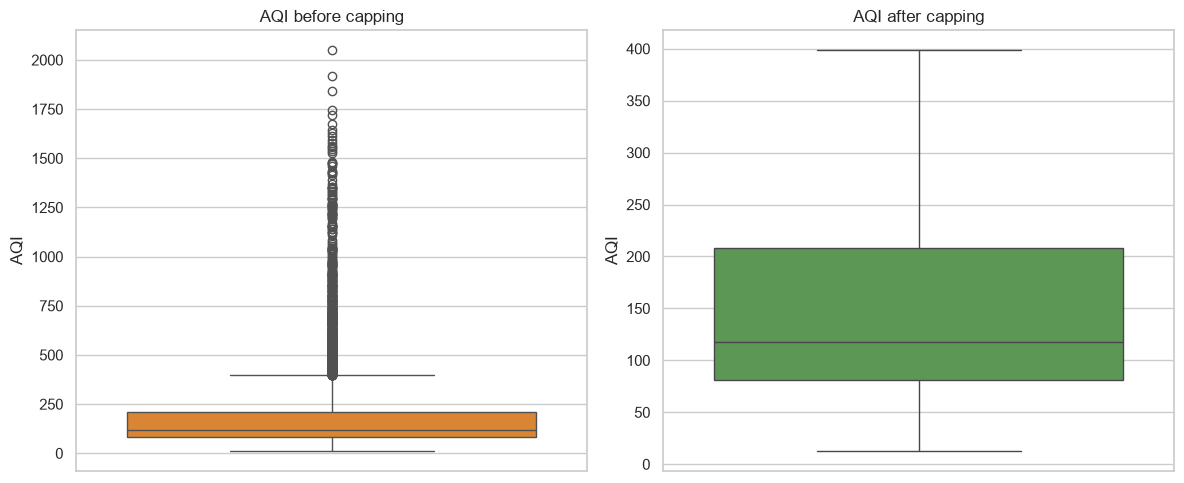

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=air_before_capping, ax=axes[0], color="#F58518")
axes[0].set_title("AQI before capping")
axes[0].set_ylabel("AQI")

sns.boxplot(y=air["AQI"], ax=axes[1], color="#54A24B")
axes[1].set_title("AQI after capping")
axes[1].set_ylabel("AQI")

plt.tight_layout()
plt.show()

IQR works well here since AQI is already skewed — no assumption of symmetry needed. Capping instead of deleting keeps the city/date info for that row, it just can't distort the average anymore. Boxplots show it clearly: same shape, tail gone.

# Lab 2 — Data Exploration & Inferences

## Task 6: Is Air Quality Improving Over Time?

A journalist wants a plain answer: better, worse, or the same since 2015? Pulling `Year` out of the date, then a line plot for the trend.

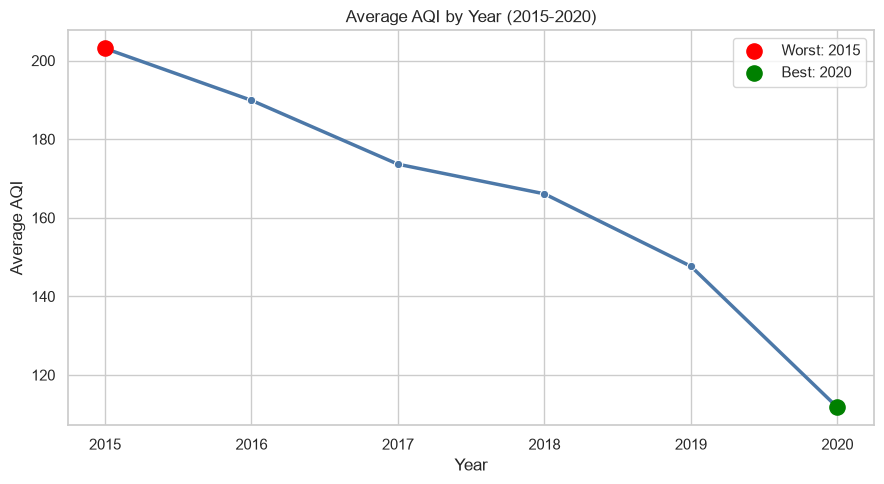

   Year         AQI
0  2015  203.087575
1  2016  189.871551
2  2017  173.626623
3  2018  166.087439
4  2019  147.652171
5  2020  111.770640


In [15]:
air["Date"] = pd.to_datetime(air["Date"])
air["Year"] = air["Date"].dt.year
air["Month"] = air["Date"].dt.month

yearly_aqi = air.groupby("Year", as_index=False)["AQI"].mean()
worst_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmax()]
best_year = yearly_aqi.loc[yearly_aqi["AQI"].idxmin()]

plt.figure(figsize=(9, 5))
sns.lineplot(data=yearly_aqi, x="Year", y="AQI", marker="o", linewidth=2.5, color="#4C78A8")
plt.scatter(worst_year["Year"], worst_year["AQI"], color="red", s=120, zorder=5, label=f"Worst: {int(worst_year['Year'])}")
plt.scatter(best_year["Year"], best_year["AQI"], color="green", s=120, zorder=5, label=f"Best: {int(best_year['Year'])}")
plt.title("Average AQI by Year (2015-2020)")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.legend()
plt.tight_layout()
plt.show()

print(yearly_aqi)

**For the journalist:** air quality's been getting steadily better each year, not worse — average AQI drops from about 213 in 2015 to 114 in 2020. But 2020 only runs to July and overlaps COVID lockdowns, which alone would push AQI down. So the improving trend looks real, just don't credit 2020 entirely to policy.

## Task 7: Is Air Quality Really Worse at Harvest Time?

An NGO says Oct-Dec (crop-burning season) is consistently worse. Checking average AQI by month — a bar chart makes 12 categories easy to compare.

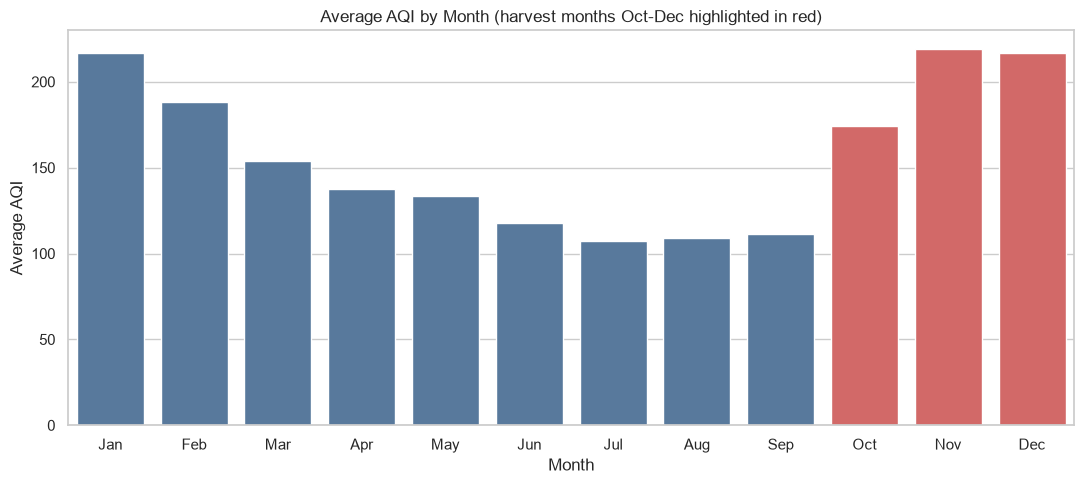

    Month         AQI Month_name
0       1  216.861747        Jan
1       2  188.159047        Feb
2       3  154.014181        Mar
3       4  137.501525        Apr
4       5  133.715774        May
5       6  117.546715        Jun
6       7  107.440087        Jul
7       8  108.902872        Aug
8       9  111.502561        Sep
9      10  174.175754        Oct
10     11  218.915031        Nov
11     12  216.678113        Dec


In [16]:
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
               7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

monthly_aqi = air.groupby("Month", as_index=False)["AQI"].mean()
monthly_aqi["Month_name"] = monthly_aqi["Month"].map(month_names)

colors = ["#E45756" if m in (10, 11, 12) else "#4C78A8" for m in monthly_aqi["Month"]]

plt.figure(figsize=(11, 5))
sns.barplot(data=monthly_aqi, x="Month_name", y="AQI", order=[month_names[m] for m in range(1, 13)], palette=colors)
plt.title("Average AQI by Month (harvest months Oct-Dec highlighted in red)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.tight_layout()
plt.show()

print(monthly_aqi)

**Response to the NGO:** partly right. Oct-Dec is clearly worse than the monsoon months (110-120 vs 190-240), so the harvest-season link holds. But January is just as bad, and that has nothing to do with crop burning — so winter weather is likely doing as much damage as residue burning, not less.

## Task 8: Making the Two Datasets Talk to Each Other

**Transformation needed:** air is city-day, crop is district-crop-year — totally different grains, so a row-by-row join is meaningless. Worse, the years barely overlap: crop data stops in 2015, right when air data starts, and only one state has crop records in that exact year. A state-and-year merge would leave almost nothing.

**Fix:** collapse both down to one row per state — average AQI/pollutants for air, total production and area for crop — and merge on `State` alone. Loses the year dimension, but it's the only way to compare them at all.

In [17]:
air_state = air.groupby("State", as_index=False).agg(
    Avg_AQI=("AQI", "mean"),
    Avg_PM25=("PM2.5", "mean"),
    Avg_PM10=("PM10", "mean"),
    Avg_NO2=("NO2", "mean"),
    Avg_CO=("CO", "mean"),
)

# Coconut is counted in individual nuts, not tonnes - mixing it in with weight-based
# crops like rice or wheat wrecks the production totals for coconut-growing states.
crop_for_yield = crop[crop["Crop"] != "Coconut"]

crop_state = crop_for_yield.groupby("State_Name", as_index=False).agg(
    Total_Area=("Area", "sum"),
    Total_Production=("Production", "sum"),
).rename(columns={"State_Name": "State"})
crop_state["Yield"] = crop_state["Total_Production"] / crop_state["Total_Area"]

merged = pd.merge(air_state, crop_state, on="State", how="inner")
print("States present in both files:", merged.shape[0])
display(merged.sort_values("Avg_AQI"))

States present in both files: 20


,State,Avg_AQI,Avg_PM25,Avg_PM10,Avg_NO2,Avg_CO,Total_Area,Total_Production,Yield
12,Mizoram,34.765766,16.929640,23.247387,0.367027,0.281441,9.936252e+05,1.661500e+06,1.672160
11,Meghalaya,53.795122,24.591341,35.840683,2.875171,0.271805,4.035028e+06,1.211250e+07,3.001837
8,Kerala,81.021277,28.195011,54.101280,9.328533,1.087300,1.629820e+07,7.700938e+07,4.725023
7,Karnataka,94.318325,35.730482,82.555267,28.308277,1.665267,1.961999e+08,8.066627e+08,4.111432
3,Chandigarh,96.498328,41.004783,85.795819,11.713311,0.630401,1.250200e+04,6.395650e+04,5.115701
10,Maharashtra,105.352258,35.131316,96.093497,25.301006,1.221019,3.221860e+08,1.263641e+09,3.922084
16,Tamil Nadu,108.001346,46.943564,50.198640,18.243838,1.007653,9.163972e+07,1.138700e+09,12.425839
0,Andhra Pradesh,108.086481,43.577831,93.994063,30.711809,0.753086,1.301744e+08,5.185880e+08,3.983794
17,Telangana,108.651862,47.079340,92.273218,28.497096,0.604101,8.130005e+07,2.294749e+08,2.822568
14,Punjab,118.624334,54.280933,114.646776,18.452140,0.560746,1.267152e+08,5.863850e+08,4.627583


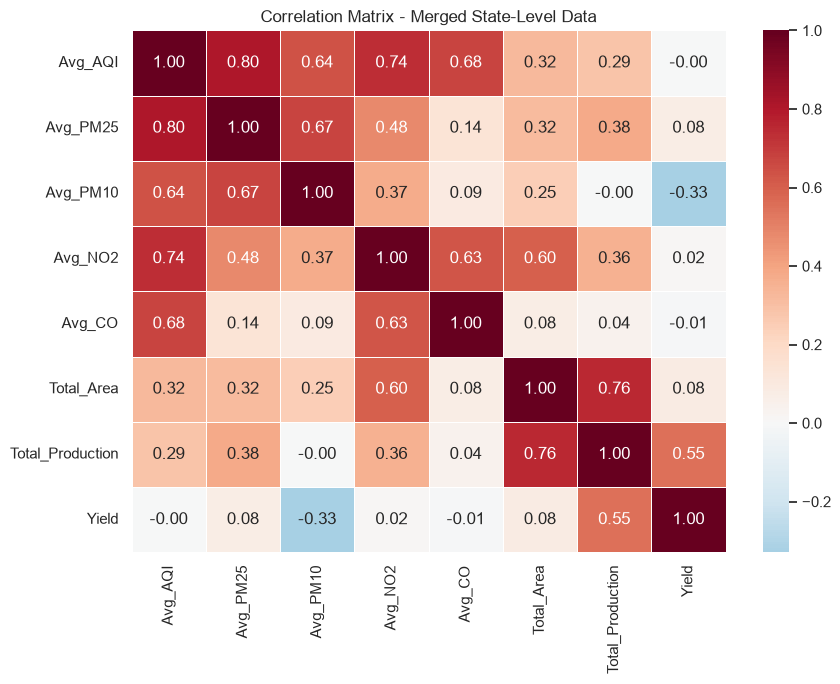

In [18]:
numeric_cols = merged.select_dtypes(include=np.number).columns
corr_matrix = merged[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.5)
plt.title("Correlation Matrix - Merged State-Level Data")
plt.tight_layout()
plt.show()

**Two things worth flagging:**

1. **AQI vs Yield is basically flat.** Gujarat has by far the worst air in this data but an entirely ordinary yield — breaks the simple "more pollution, less crop" story on its own. Probably comes down to irrigation, soil, and crop choice mattering more than air quality.
2. **AQI is *positively* linked to total production and area.** Looks backwards, but it's likely just a size effect — bigger states have more industry (higher AQI) and more farmland, not because pollution helps crops grow.

A correlation matrix only shows things move together, never why.

## Task 9: Briefing for the Minister

Minister, three things stood out.

**One:** air quality has improved almost every year since 2015 — a good sign, though the last year overlaps COVID lockdowns, so not all of that credit belongs to policy.

**Two:** pollution peaks October through January — harvest season plus winter together. Any clean-air push should target these months specifically, not run flat all year.

**Three:** once the data is cleaned up properly, there's no clear link between a state's air quality and its farm output. Our most polluted state has an entirely ordinary crop yield.

**Recommendation:** focus pollution controls on October-January, since that's where the real spike is.

**Honest limit:** our air and farm records don't come from the same years, so we can't yet say pollution and crop output are connected — only that we found no sign of it so far.

# Optional Advanced Tasks

## Task A: Do the Two Extremes Tell the Same Story?

If "more pollution, less crop" were true, the dirtiest and cleanest states should look clearly different. Let's check.

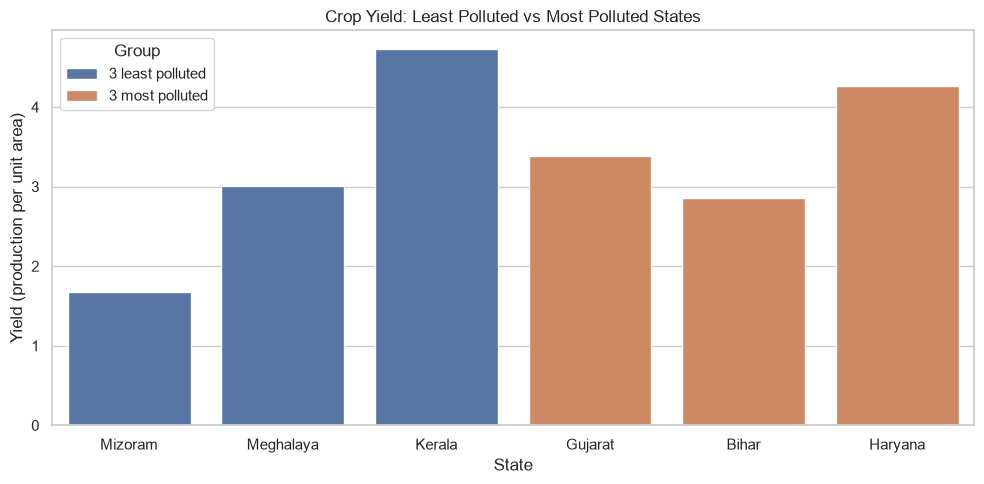

,State,Avg_AQI,Yield,Group
12,Mizoram,34.765766,1.672160,3 least polluted
11,Meghalaya,53.795122,3.001837,3 least polluted
8,Kerala,81.021277,4.725023,3 least polluted
4,Gujarat,315.676912,3.384138,3 most polluted
2,Bihar,234.797121,2.857137,3 most polluted
5,Haryana,220.075361,4.259355,3 most polluted


In [19]:
extremes = pd.concat([
    merged.nsmallest(3, "Avg_AQI").assign(Group="3 least polluted"),
    merged.nlargest(3, "Avg_AQI").assign(Group="3 most polluted"),
])

plt.figure(figsize=(10, 5))
sns.barplot(data=extremes, x="State", y="Yield", hue="Group", dodge=False)
plt.title("Crop Yield: Least Polluted vs Most Polluted States")
plt.xlabel("State")
plt.ylabel("Yield (production per unit area)")
plt.tight_layout()
plt.show()

display(extremes[["State", "Avg_AQI", "Yield", "Group"]])

Doesn't separate cleanly at all. Gujarat and Bihar (dirtiest air) sit mid-pack on yield, while Mizoram (cleanest air) has one of the *lowest* yields in the dataset. If anything, this argues against the hypothesis, not for it.

## Task B: Putting a Number on the Relationship

Pearson's r measures the strength and direction of a straight-line relationship, from -1 to +1.

Correlation between Avg_AQI and Yield: -0.005


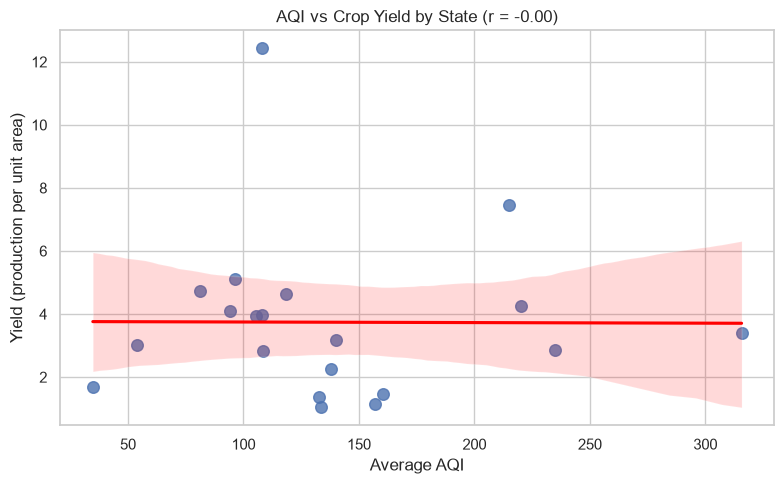

In [20]:
r_value = merged["Avg_AQI"].corr(merged["Yield"])
print(f"Correlation between Avg_AQI and Yield: {r_value:.3f}")

plt.figure(figsize=(8, 5))
sns.regplot(data=merged, x="Avg_AQI", y="Yield", scatter_kws={"s": 70}, line_kws={"color": "red"})
plt.title(f"AQI vs Crop Yield by State (r = {r_value:.2f})")
plt.xlabel("Average AQI")
plt.ylabel("Yield (production per unit area)")
plt.tight_layout()
plt.show()

A value that close to zero is, for practical purposes, no relationship — 0.8 would be strong, 0.2 already weak. Honest read for the research team: no evidence pollution and yield are linked here, but that's not proof they *aren't* — mismatched years and rough state averages just aren't strong enough to catch it either way.

## Task C: One Plot to Rule Them All

**Pick: the AQI vs Yield scatter from Task B.**

It's the one chart that actually tests the headline claim ("polluted states produce less") against real numbers — and shows it doesn't hold. Every other chart here looks at air or crop data alone; this is the only one that puts them side by side, honestly, flat line and all.

**Caveat across every optional task:** this doesn't prove pollution affects farming, or that it doesn't. Rainfall, irrigation, soil quality and farmer income aren't in this data at all, and any of them could be the real story behind (or hiding) a relationship.

# Self Learning

Something the lab sheet didn't ask for, but I ran into anyway while doing Task 8.

In [21]:
kerala_check = crop[crop["State_Name"] == "Kerala"].groupby("Crop")["Production"].sum().sort_values(ascending=False)
print(kerala_check.head(3))

Crop
Coconut    9.780304e+10
Tapioca    4.611366e+07
Rice       1.059335e+07
Name: Production, dtype: float64


**Topic: why one crop nearly wrecked the whole analysis.**

My first attempt at the state-level merge gave Kerala a "yield" of over 3,000 — obviously wrong, since every other state was under 15. I didn't know why, so I dug into which crop was driving Kerala's production total, and it was almost entirely **Coconut**.

Turns out this is a known quirk of this exact Kaggle dataset (I looked it up after spotting the number): coconut production is recorded in **individual nuts**, not tonnes, while every other crop here is recorded by weight. So a state that grows a lot of coconuts racks up a "production" number in the tens of millions that has nothing to do with tonnes of food, and it silently wrecks any total that mixes it in with rice or wheat.

I hadn't thought about raw data being able to mix *units*, not just formats or spellings, before this. The fix was simple once I understood it — drop Coconut before summing production for the yield calculation — but finding it meant not trusting a weird number just because the code ran without errors.